# Setup

In [ ]:
!pip install google-adk

In [ ]:
from IPython.display import HTML, Markdown, display

In [ ]:
from google.colab import userdata
api_key = userdata.get('GOOGLE_API_KEY')

In [ ]:
import os
from google import genai
from google.genai import types
from google.adk.agents import LlmAgent
from google.adk.models.google_llm import Gemini
from google.adk.runners import InMemoryRunner
from google.adk.sessions import InMemorySessionService
from google.adk.tools import google_search, AgentTool, ToolContext
from google.adk.code_executors import BuiltInCodeExecutor

In [ ]:
def show_python_code_and_result(response):
  # Helper function that prints the generated Python code and results from the code execution tool
  for i in range(len(response)):
    # Check if the response contains a valid function call result from the code executor
    if (
        (response[i].content.parts)
        and (response[i].content.parts[0])
        and (response[i].content.parts[0].function_response)
        and (response[i].content.parts[0].function_response.response)
    ):
      response_code = response[i].content.parts[0].function_response.response
      if "result" in response_code and response_code["result"] != "```":
        if "tool_code" in response_code["result"]:
          print(
              "Generated Python Code >> ",
              response_code["result"].replace("tool_code", ""),
          )
        else:
          print("Generated Python Response >> ", response_code["result"])

In [ ]:
retry_config = types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504],  # Retry on these HTTP errors
)

In [ ]:
# Set API key as environment variable
os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')

client = genai.Client(api_key=api_key)

for model in client.models.list():
  print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025
models/ge

# 1. Agent Tools

Agent tools are not just limited to the built-in tools provided by the adk but can also be defined as per requirements as functions.

These tools can be delegated to specialist agents allowing us to handle real world complexities.

### 1.1) Why does agent need tools?

The problem with LLMs is that their knowledge is frozen in time: it can't access today's news or your company's inventory. It has no connection to the outside world, so the agent can't take actions for you.

`Tools are what transform your isolated LLM into a capable agent that can actually help you get things done.`

### 1.2) Custom Tools

Custom Tools are tools you build yourself using your own code and business logic. Unlike built-in tools that come ready-made with ADK, custom tools give you complete control over functionality.

- <b><u>When to use custom tools</b></u> <br>
Every business has unique requirements that generic tools can't handle. Custom tools let you implement your specific business logic, connect to your systems, and solve domain-specific problems. ADK provides multiple custom tool types to handle these scenarios.

### 1.3) Building a Custom Function Tool: Currency Converter

This agent can convert currency from one denomination to another and calculates the fees to do the conversion. The agent has two custom tools and follows the workflow:

1. `Fee Lookup Tool` - Finds transaction fees for the conversion (mock)
2. `Exchange Rate Tool` - Gets currency conversion rates (mock)
3. `Calculation Step` - Calculates the total conversion cost including the fees

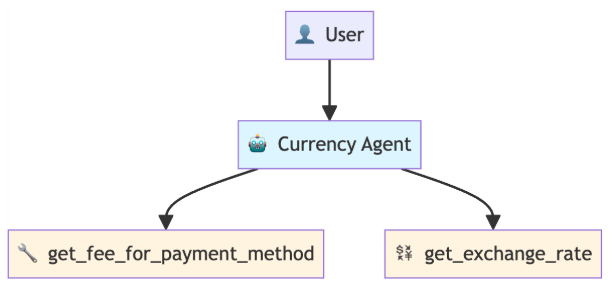

#### 1.3.1) Defining a Tool

Any Python function can become an agent tool by following these simple guidelines:

- Create a Python function
- Follow the best practices listed below
- Add your function to the agent's `tools=[]` list and ADK handles the rest automatically.

<b><u>ADK Best Practices</u></b>

1. `Dictionary Returns`: Tools return `{"status": "success", "data": ...}` or `{"status": "error", "error_message": ...}`
2. `Clear Docstrings`: LLMs use docstrings to understand when and how to use tools
3. `Type Hints`: Enable ADK to generate proper schemas (str, dict, etc.)
4. `Error Handling`: Structured error responses help LLMs handle failures gracefully

These patterns make your tools reliable and easy for LLMs to use correctly.

In [ ]:
def get_fee_for_payment_method(method: str) -> dict:
    """Looks up the transaction fee percentage for a given payment method.

    This tool simulates looking up a company's internal fee structure based on
    the name of the payment method provided by the user.

    Args:
        method: The name of the payment method. It should be descriptive,
                e.g., "platinum credit card" or "bank transfer".

    Returns:
        Dictionary with status and fee information.
        Success: {"status": "success", "fee_percentage": 0.02}
        Error: {"status": "error", "error_message": "Payment method not found"}
    """
    # This simulates looking up a company's internal fee structure.
    fee_database = {
        "platinum credit card": 0.02,  # 2%
        "gold debit card": 0.035,  # 3.5%
        "bank transfer": 0.01,  # 1%
    }

    fee = fee_database.get(method.lower())
    if fee is not None:
        return {"status": "success", "fee_percentage": fee}
    else:
        return {
            "status": "error",
            "error_message": f"Payment method '{method}' not found",
        }

print(f"Test: {get_fee_for_payment_method('platinum credit card')}")

Test: {'status': 'success', 'fee_percentage': 0.02}


In [ ]:
def get_exchange_rate(base_currency: str, target_currency: str) -> dict:
    """Looks up and returns the exchange rate between two currencies.

    Args:
        base_currency: The ISO 4217 currency code of the currency you
                       are converting from (e.g., "USD").
        target_currency: The ISO 4217 currency code of the currency you
                         are converting to (e.g., "EUR").

    Returns:
        Dictionary with status and rate information.
        Success: {"status": "success", "rate": 0.93}
        Error: {"status": "error", "error_message": "Unsupported currency pair"}
    """

    # Static data simulating a live exchange rate API
    # In production, this would call something like: requests.get("api.exchangerates.com")
    rate_database = {
        "usd": {
            "eur": 0.93,  # Euro
            "jpy": 157.50,  # Japanese Yen
            "inr": 83.58,  # Indian Rupee
        }
    }

    # Input validation and processing
    base = base_currency.lower()
    target = target_currency.lower()

    # Return structured result with status
    rate = rate_database.get(base, {}).get(target)
    if rate is not None:
        return {"status": "success", "rate": rate}
    else:
        return {
            "status": "error",
            "error_message": f"Unsupported currency pair: {base_currency}/{target_currency}",
        }

print(f"Test: {get_exchange_rate('USD', 'EUR')}")

Test: {'status': 'success', 'rate': 0.93}


#### 1.3.2) Defining Agent

- The `tools=[]` list tells the agent which functions it can use
- Instructions reference tools by their exact function names (e.g., `get_fee_for_payment_method()`)
- The agent uses these names to decide when and how to call each tool

In [ ]:
# Creating Currency Agent with Custom Tools
currency_agent = LlmAgent(
    name="currency_agent",
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    instruction="""You are a smart currency conversion assistant.

    For currency conversion requests:
    1. Use `get_fee_for_payment_method()` to find transaction fees
    2. Use `get_exchange_rate()` to get currency conversion rates
    3. Check the "status" field in each tool's response for errors
    4. Calculate the final amount after fees based on the output from `get_fee_for_payment_method` and `get_exchange_rate` methods and provide a clear breakdown.
    5. First, state the final converted amount.
        Then, explain how you got that result by showing the intermediate amounts. Your explanation must include: the fee percentage and its
        value in the original currency, the amount remaining after the fee, and the exchange rate used for the final conversion.

    If any tool returns status "error", explain the issue to the user clearly.
    """,
    tools=[get_fee_for_payment_method, get_exchange_rate],
)

print("Currency agent created with custom function tools")
print("Available tools:")
print("  • get_fee_for_payment_method - Looks up company fee structure")
print("  • get_exchange_rate - Gets current exchange rates")

Currency agent created with custom function tools
Available tools:
  • get_fee_for_payment_method - Looks up company fee structure
  • get_exchange_rate - Gets current exchange rates


In [ ]:
currency_runner = InMemoryRunner(agent=currency_agent)
_ = await currency_runner.run_debug(
    "I want to convert 500 US Dollars to Euros using my Platinum Credit Card. How much will I receive?"
)


 ### Created new session: debug_session_id

User > I want to convert 500 US Dollars to Euros using my Platinum Credit Card. How much will I receive?


currency_agent > I will receive €455.70.

Here's how this amount was calculated:

1. **Fee deduction:** A fee of 2% is charged for using a platinum credit card. This amounts to $10.00 (500 USD * 0.02).
2. **Amount after fee:** After deducting the fee, you have $490.00 remaining (500 USD - 10 USD).
3. **Currency conversion:** The exchange rate between USD and EUR is 0.93. So, $490.00 is converted to €455.70 (490 USD * 0.93).


### 1.4) Improving Agent Reliability with Code

The agent's instruction says *"calculate the final amount after fees"* but LLMs aren't always reliable at math. They might make calculation errors or use inconsistent formulas.

In these scanarious a solution can be to ask the agent to generate a python code to do the math, run it and then give the final result. Code execution is much more reliable than having LLM do the math in its head.

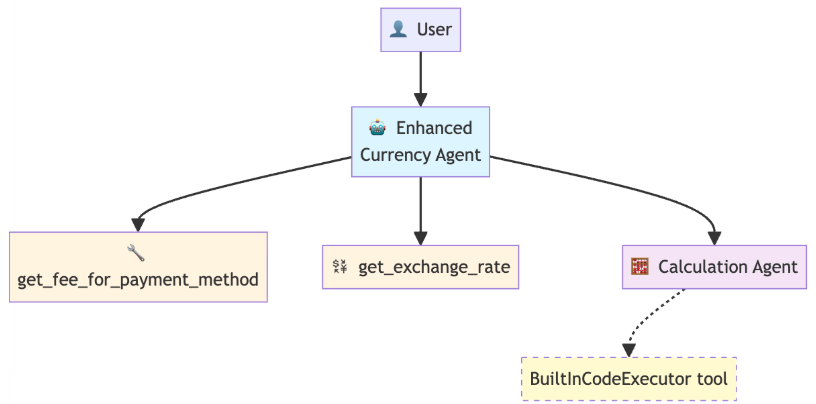

#### 1.4.1) Built-in Code Executor

ADK has a built-in Code Executor capable of running code in a sandbox.

**Note: This uses Gemini's Code Execution capability.**

Let's create a `calculation_agent` which takes in a Python code and uses the `BuiltInCodeExecutor` to run it.

In [ ]:
calculation_agent = LlmAgent(
    name="CalculationAgent",
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    instruction="""You are a specialized calculator that ONLY responds with Python code. You are forbidden from providing any text, explanations, or conversational responses.

     Your task is to take a request for a calculation and translate it into a single block of Python code that calculates the answer.

     **RULES:**
    1.  Your output MUST be ONLY a Python code block.
    2.  Do NOT write any text before or after the code block.
    3.  The Python code MUST calculate the result.
    4.  The Python code MUST print the final result to stdout.
    5.  You are PROHIBITED from performing the calculation yourself. Your only job is to generate the code that will perform the calculation.

    Failure to follow these rules will result in an error.
       """,
    code_executor=BuiltInCodeExecutor(),  # the built-in Code Executor Tool gives the agent code execution capabilities
)

#### 1.4.2) Updating Agents' instruction and toolset

Here we need to perform 2 main actions:

1. **Update the currency_agent's instructions to generate Python code**
  - Original: *"Calculate the final amount after fees" (vague math instructions)*
  - Enhanced: *"Generate a Python code to calculate the final amount .. and use the calculation_agent to run the code and compute final amount"*

2. **Add the `calculation_agent` to the toolset**
  - ADK lets you use any agent as a tool using `AgentTool`.
  - Add `AgentTool(agent=calculation_agent)` to the tools list
  - The specialist agent appears as a callable tool to the root agent

In [ ]:
enhanced_currency_agent = LlmAgent(
    name="enhanced_currency_agent",
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    # Updated instruction
    instruction="""You are a smart currency conversion assistant. You must strictly follow these steps and use the available tools.

  For any currency conversion request:

   1. Get Transaction Fee: Use the get_fee_for_payment_method() tool to determine the transaction fee.
   2. Get Exchange Rate: Use the get_exchange_rate() tool to get the currency conversion rate.
   3. Error Check: After each tool call, you must check the "status" field in the response. If the status is "error", you must stop and clearly explain the issue to the user.
   4. Calculate Final Amount (CRITICAL): You are strictly prohibited from performing any arithmetic calculations yourself. You must use the calculation_agent tool to generate Python code that calculates the final converted amount. This
      code will use the fee information from step 1 and the exchange rate from step 2.
   5. Provide Detailed Breakdown: In your summary, you must:
       * State the final converted amount.
       * Explain how the result was calculated, including:
           * The fee percentage and the fee amount in the original currency.
           * The amount remaining after deducting the fee.
           * The exchange rate applied.
    """,
    tools=[
        get_fee_for_payment_method,
        get_exchange_rate,
        AgentTool(agent=calculation_agent),  # Using another agent as a tool!
    ],
)

In [ ]:
enhanced_runner = InMemoryRunner(agent=enhanced_currency_agent)

In [ ]:
response = await enhanced_runner.run_debug(
    "Convert 1,250 USD to INR using a Bank Transfer. Show me the precise calculation."
)


 ### Created new session: debug_session_id

User > Convert 1,250 USD to INR using a Bank Transfer. Show me the precise calculation.
enhanced_currency_agent > The final converted amount is 103,430.25 INR.

Here's the breakdown of the calculation:

1.  **Transaction Fee:** A 1% fee was applied to the original amount, resulting in a fee of 12.50 USD.
2.  **Amount After Fee:** After deducting the fee, 1,237.50 USD remained.
3.  **Exchange Rate:** The exchange rate used for the conversion was 83.58 INR per USD.
4.  **Final Calculation:** The remaining amount (1,237.50 USD) was converted to INR using the exchange rate, yielding the final amount of 103,430.25 INR.


In the above cell execution when the `Currency agent` calls the `CalculationAgent`, it passes in the generated Python code.

The `CalculationAgent` in turn used the `BuiltInCodeExecutor` to run the code and gave us precise calculations instead of LLM guesswork.

### 1.5) Difference between Agent Tools V/S Sub Agents

Both of them involve use of multiple agents but the working is quite different:

- Agent Tools (Used in currency example):
  - Agent A calls Agent B as a tool
  - Agent B's response goes back to Agent A
  - Agent A stays in control and continues the conversation
  - Use case: Delegation for specific tasks (like calculations)

- Sub-Agents (different pattern):
  - Agent A transfers control completely to Agent B
  - Agent B takes over and handles all future user input
  - Agent A is out of the loop
  - Use case: Handoff to specialists (like customer support tiers)

In our currency example: We want the currency agent to get calculation results and continue working with them, so we use Agent Tools, not sub-agents.

### 1.6) ADK Tool Types

The complete ADK toolkit is broadly divided into 2 categories: **Custom Tools** and **Built-In Tools**.

#### 1.6.1) Custom Tools

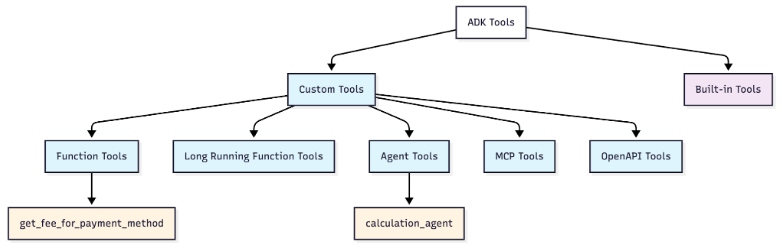

**What**: Tools you build yourself for specific needs

**Advantage**: Complete control over functionality — you build exactly what your agent needs

1. **Function Tools** (Used in Currency example)
  - `What`: Python functions converted to agent tools
  - `Examples`: get_fee_for_payment_method, get_exchange_rate
  - `Advantage`: Turn any Python function into an agent tool instantly

2. **Long Running Function Tools**
  - `What`: Functions for operations that take significant time
  - `Examples`: Human-in-the-loop approvals, file processing
  - `Advantage`: Agents can start tasks and continue with other work while waiting

3. **Agent Tools** (Used in Currency example)
  - `What`: Other agents used as tools
  - `Examples`: AgentTool(agent=calculation_agent)
  - `Advantage`: Build specialist agents and reuse them across different systems

4. **MCP Tools**
  - `What`: Tools from Model Context Protocol servers
  - `Examples`: Filesystem access, Google Maps, databases
  - `Advantage`: Connect to any MCP-compatible service without custom integration

5. **OpenAPI Tools**
  - `What`: Tools automatically generated from API specifications
  - `Examples`: REST API endpoints become callable tools
  - `Advantage`: No manual coding — just provide an API spec and get working tools

#### 1.6.2) Built-In Tools

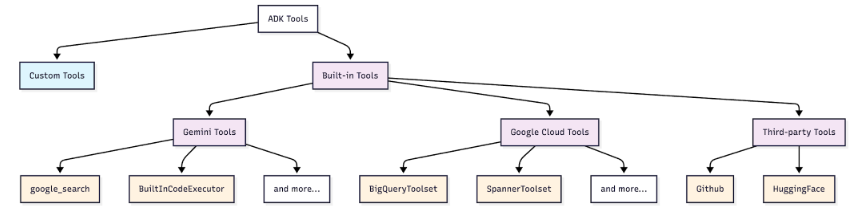

**What**: Pre-built tools provided by ADK

**Advantage**: No development time — use immediately with zero setup

1. **Gemini Tools** (Used in Previous Notebook and currency example)
  - `What`: Tools that leverage Gemini's capabilities
  - `Examples`: google_search, BuiltInCodeExecutor
  - `Advantage`: Reliable, tested tools that work out of the box

2. **Google Cloud Tools** `[needs Google Cloud access]`
  - `What`: Tools for Google Cloud services and enterprise integration
  - `Examples`: BigQueryToolset, SpannerToolset, APIHubToolset
  - `Advantage`: Enterprise-grade database and API access with built-in security

3. **Third-party Tools**
  - `What`: Wrappers for existing tool ecosystems
  - `Examples`: Hugging Face, Firecrawl, GitHub Tools
  - `Advantage`: Reuse existing tool investments — no need to rebuild what already exists

# 2.) Using Model Context Protocol (MCP)

This section is all about consuming external MCP serrvices and handling long running operations. This includes:
- Connecting to external MCP services.
- Implement long running operations that can pause agent execution for external input.
- Build resumable workflows that maintain state across conversation breaks.
- Understanding when and how to use these patterns.

`NOTE: Execute this section in local environment for learning purposes.`

In [ ]:
# Loading necessary modules
import uuid
from google.genai import types

from google.adk.agents import LlmAgent
from google.adk.models.google_llm import Gemini
from google.adk.runners import Runner, InMemoryRunner
from google.adk.sessions import InMemorySessionService

from google.adk.tools.mcp_tool.mcp_toolset import McpToolset
from google.adk.tools.tool_context import ToolContext
from google.adk.tools.mcp_tool.mcp_session_manager import StdioConnectionParams
from mcp import StdioServerParameters

from google.adk.apps.app import App, ResumabilityConfig
from google.adk.tools.function_tool import FunctionTool

### 2.1) What is Model Context Protocol (MCP)

So far we have written custom function for our agents to be used as tools, but when it comes to external systems like databases, github, etc. we need to write APIs and maintain API Clients.

MCP is an open standard that lets agents use community-built integrations. Instead of writing our own integrations and API clients, we can just connect to an existing MCP server.

MCP enables agents to:

- Access live, external data from databases, APIs, and services without custom integration code
- Leverage community-built tools with standardized interfaces
- Scale capabilities by connecting to multiple specialized servers

#### 2.1.1) How MCP Works

MCP connects your agent (the client) to external MCP servers that provide tools:

- **MCP Server**: Provides specific tools (like image generation, database access)
- **MCP Client**: Your agent that uses those tools
- **All servers work the same way** - standardized interface

**Architecture**:<br>

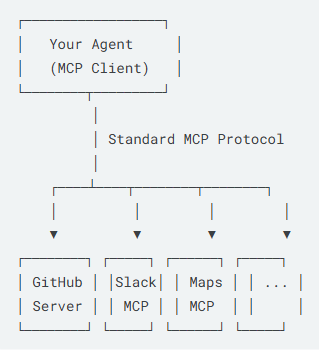

#### 2.1.2) Using MCP with Agent

The workflow is simple:

1. Choose an MCP Server and tool
2. Create the MCP Toolset (configure connection)
3. Add it to your agent
4. Run and test the agent
<br>

**Step 1: Choose MCP Server**

For this demo, we'll use the `Everything MCP Server` - an npm package (`@modelcontextprotocol/server-everything`) designed for testing MCP integrations.

It provides a getTinyImage tool that returns a simple test image (16x16 pixels, Base64-encoded).

*Find more servers: See references link 4 and 5*

<br>

<b><u>`NOTE: This is a demo server to learn MCP. In production, we use servers for Google Maps, Slack, Discord, etc.`</b></u>

<br>

**Step 2: Create the MCP Toolset**

The McpToolset is used to integrate an ADK Agent with an MCP Server.

**What the code does:**

- Uses `npx` (Node package runner) to run the MCP server
- Connects to `@modelcontextprotocol/server-everything`
- Filters to only use the `getTinyImage` tool (the server has others, but we only need this one)

<h4><b><u>This section of code will run only on Kaggle and linux servers/systems, for others you will need to do all the steps manually.</u></b></h4>

In [ ]:
# MCP integration with Everything Server
mcp_image_server = McpToolset(
    connection_params=StdioConnectionParams(
        server_params=StdioServerParameters(
            command="npx",  # Run MCP server via npx
            args=[
                "-y",  # Argument for npx to auto-confirm install
                "@modelcontextprotocol/server-everything",
            ],

        ),
        tool_filter=["getTinyImage"],
        timeout=30,
    )
)

print("MCP Tool created")

MCP Tool created


Behind the scenes:

1. **Server Launch**: ADK runs `npx -y @modelcontextprotocol/server-everything`
2. **Handshake**: Establishes stdio communication channel
3. **Tool Discovery**: Server tells ADK: "I provide getTinyImage" functionality
4. **Integration**: Tools appear in agent's tool list automatically
5. **Execution**: When agent calls getTinyImage(), ADK forwards to MCP server
6. **Response**: Server result is returned to agent seamlessly

**Why This Matters**: You get instant access to tools without writing integration code!



---

**Step 3: Add MCP tool to agent**

Let's add the `mcp_server` to the agent's tool array and update the agent's instructions to handle requests to generate tiny images.

In [ ]:
# Create image agent with MCP integration
image_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="image_agent",
    instruction="Use the MCP Tool to generate images for user queries",
    tools=[mcp_image_server],
)

In [ ]:
runner = InMemoryRunner(agent=image_agent)



---

**Step 4: Test the agent**

Here we ask the agent to genrate an image which it does using the MCP tool.

In [ ]:
response = await runner.run_debug("Provide a sample tiny image", verbose=True)

In [ ]:
# The server returns base64-encoded image data. Let's decode and display it
from IPython.display import display, Image as IPImage
import base64

for event in response:
    if event.content and event.content.parts:
        for part in event.content.parts:
            if hasattr(part, "function_response") and part.function_response:
                for item in part.function_response.response.get("content", []):
                    if item.get("type") == "image":
                        display(IPImage(data=base64.b64decode(item["data"])))

#### 2.1.3) Extending to other MCP Servers

The same pattern works for any MCP server - only the `connection_params` change.

**Kaggle MCP Server** - For dataset and notebook operations

Kaggle provides an MCP server that lets your agents interact with Kaggle datasets, notebooks, and competitions.

Connection example:

```
McpToolset(
    connection_params=StdioConnectionParams(
        server_params=StdioServerParameters(
            command='npx',
            args=[
                '-y',
                'mcp-remote',
                'https://www.kaggle.com/mcp'
            ],
        ),
        timeout=30,
    )
)
```

What it provides:
- Search and download Kaggle datasets
- Access notebook metadata
- Query competition information etc.,

Refer: <a href="https://www.kaggle.com/docs/mcp">Kaggle MCP Documentation</a>



---

**GitHub MCP Server** - For PR/Issue analysis

```
McpToolset(
    connection_params=StreamableHTTPServerParams(
        url="https://api.githubcopilot.com/mcp/",
        headers={
            "Authorization": f"Bearer {GITHUB_TOKEN}",
            "X-MCP-Toolsets": "all",
            "X-MCP-Readonly": "true"
        },
    ),
)
```

Refer: <a href="https://google.github.io/adk-docs/integrations/">Google ADK 3rd Party MCP Tools</a>

### 2.2) Long-Running Operations (Human-in-the-Loop)

So far, all tools execute and return immediately:

`User asks → Agent calls tool → Tool returns result → Agent responds`

But what if your tools are long-running or you need human approval before completing an action?

Example: A shipping agent should ask for approval before placing a large order.

`User asks → Agent calls tool → Tool PAUSES and asks human → Human approves → Tool completes → Agent responds`

This is called a **Long-Running Operation (LRO)** - the tool needs to pause, wait for external input (human approval), then resume.

When to use Long-Running Operations:

- Financial transactions requiring approval (transfers, purchases)
- Bulk operations (delete 1000 records - confirm first!)
- Compliance checkpoints (regulatory approval needed)
- High-cost actions (spin up 50 servers - are you sure?)
- Irreversible operations (permanently delete account)

#### 2.2.1) Example: Shipping Coordinator Agent with Single Tool

This agent will have 1 tool that:
- Auto-approves small orders (≤5 containers)
- **Pauses and asks for approval** on large orders (>5 containers)
- Completes or cancels based on the approval decision.

This demonstrates the core long-running operation pattern: `pause → wait for human input → resume`.

#### 2.2.2) Shipping Tool With Approval Logic

The `ToolContext` Parameter
Notice the function signature includes `tool_context: ToolContext`. ADK automatically provides this object when your tool runs. It gives you two key capabilities:

- Request approval: Call `tool_context.request_confirmation()`
- Check approval status: Read `tool_context.tool_confirmation`

In [ ]:
LARGE_ORDER_THRESHOLD = 5


def place_shipping_order(num_containers: int, destination: str, tool_context: ToolContext) -> dict:
    """Places a shipping order. Requires approval if ordering more than 5 containers (LARGE_ORDER_THRESHOLD).

    Args:
        num_containers: Number of containers to ship
        destination: Shipping destination

    Returns:
        Dictionary with order status
    """

    # SCENARIO 1: Small orders (≤5 containers) auto-approve
    if num_containers <= LARGE_ORDER_THRESHOLD:
        return {
            "status": "approved",
            "order_id": f"ORD-{num_containers}-AUTO",
            "num_containers": num_containers,
            "destination": destination,
            "message": f"Order auto-approved: {num_containers} containers to {destination}",
        }

    # SCENARIO 2: This is the first time this tool is called. Large orders need human approval - PAUSE here.
    if not tool_context.tool_confirmation:
        tool_context.request_confirmation(
            hint=f"Large order: {num_containers} containers to {destination}. Do you want to approve?",
            payload={"num_containers": num_containers, "destination": destination},
        )
        return {  # This is sent to the Agent
            "status": "pending",
            "message": f"Order for {num_containers} containers requires approval",
        }

    # SCENARIO 3: The tool is called AGAIN and is now resuming. Handle approval response - RESUME here.
    if tool_context.tool_confirmation.confirmed:
        return {
            "status": "approved",
            "order_id": f"ORD-{num_containers}-HUMAN",
            "num_containers": num_containers,
            "destination": destination,
            "message": f"Order approved: {num_containers} containers to {destination}",
        }
    else:
        return {
            "status": "rejected",
            "message": f"Order rejected: {num_containers} containers to {destination}",
        }

#### 2.2.3) Understanding the Code

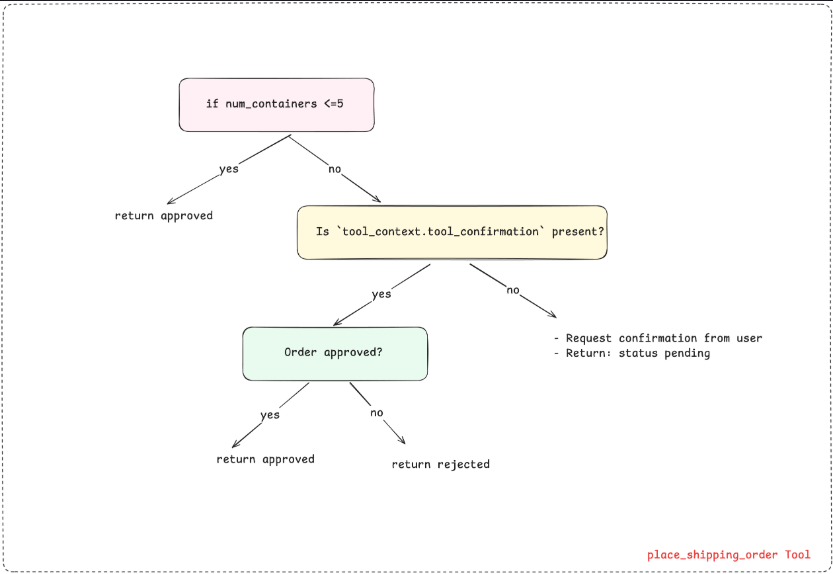

<b>How the Three Scenarios Work</b>

The tool handles three scenarios by checking `tool_context.tool_confirmation`:

- Scenario 1: `Small order (≤5 containers)`: Returns immediately with auto-approved status.

`tool_context.tool_confirmation` is never checked

- Scenario 2: `Large order - FIRST CALL`
  - Tool detects it's a first call: `if not tool_context.tool_confirmation`:
  - Calls `request_confirmation()` to request human approval
  - Returns `{'status': 'pending', ...}` immediately
  - <b>ADK automatically creates `adk_request_confirmation` event</b>
  - Agent execution pauses - waiting for human decision

- Scenario 3: `Large order - RESUMED CALL`
  - Tool detects it's resuming: `if not tool_context.tool_confirmation:` is now False
  - Checks human decision: `tool_context.tool_confirmation.confirmed`
  - If True → Returns approved status
  - If False → Returns rejected status

**Key insight**: Between the two calls, your workflow code must detect the `adk_request_confirmation` event and resume with the approval decision.

#### 2.2.4) Creating the agent, app and Runner

**Step 1: Create the agent**

Add the tool to the Agent. The tool decides internally when to request approval based on the order size.

In [ ]:
# Create shipping agent with pausable tool
shipping_agent = LlmAgent(
    name="shipping_agent",
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    instruction="""You are a shipping coordinator assistant.

  When users request to ship containers:
   1. Use the place_shipping_order tool with the number of containers and destination
   2. If the order status is 'pending', inform the user that approval is required
   3. After receiving the final result, provide a clear summary including:
      - Order status (approved/rejected)
      - Order ID (if available)
      - Number of containers and destination
   4. Keep responses concise but informative
  """,
    tools=[FunctionTool(func=place_shipping_order)],
)


**Step 2: Wrap in resumable App**

- `Problem`: A regular `LlmAgent` is stateless - each call is independent with no memory of previous interactions. If a tool requests approval, the agent can't remember what it was doing.

- `Solution`: Wrap your agent in an `App` with **resumability enabled**. The App adds a persistence layer that saves and restores state.

**What gets saved when a tool pauses:**

- All conversation messages so far
- Which tool was called (`place_shipping_order`)
- Tool parameters (10 containers, Rotterdam)
- Where exactly it paused (waiting for approval)

When you resume, the App loads this saved state so the agent continues exactly where it left off - as if no time passed.

In [ ]:
# Wrapping the agent in a resumable app - THIS IS THE KEY FOR LONG-RUNNING OPERATIONS!
shipping_app = App(
    name="shipping_coordinator",
    root_agent=shipping_agent,
    resumability_config=ResumabilityConfig(is_resumable=True),
)

/tmp/ipykernel_186/1533804428.py:5: UserWarning: [EXPERIMENTAL] ResumabilityConfig: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  resumability_config=ResumabilityConfig(is_resumable=True),


**Step 3: Create Session and Runner with the App**

Pass `app=shipping_app` instead of `agent=...` so the runner knows about resumability.

In [ ]:
session_service = InMemorySessionService()

# Create runner with the resumable app
shipping_runner = Runner(
    app=shipping_app,  # Pass the app instead of the agent
    session_service=session_service,
)

### 2.3) Building the Workflow

- **The Critical Part - Handling Events in Your Workflow**

The agent won't automatically handle pause/resume. *Every long-running operation workflow requires you to*:
  - `Detect the pause`: Check if events contain `adk_request_confirmation`
  - `Get human decision`: In production, show UI and wait for user click. Here, we simulate it.
  - `Resume the agent`: Send the decision back with the saved `invocation_id`

<br>

- **Understand Key Technical Concepts**

  - `events` - ADK creates events as the agent executes. Tool calls, model responses, function results - all become events

  - `adk_request_confirmation event` - This event is special - it signals "pause here!"
    - Automatically created by ADK when your tool calls `request_confirmation()`
    - Contains the `invocation_id`
    - Your workflow must detect this event to know the agent paused
  
  - invocation_id - Every call to `run_async()` gets a unique `invocation_id` (like "abc123")
    - When a tool pauses, you save this ID
    - When resuming, pass the same ID so ADK knows which execution to continue
    - Without it, ADK would start a NEW execution instead of resuming the paused one

<br>

- **Helper Functions to Process Events**
  
  These handle the event iteration logic for you.
  
  `check_for_approval()` - Detects if the agent paused
  - Loops through all events and looks for the special `adk_request_confirmation` event
  - Returns `approval_id` (identifies this specific request) and `invocation_id` (identifies which execution to resume)
  - Returns `None` if no pause detected

In [ ]:
def check_for_approval(events):
  """Check if events contain an approval request.

  Returns:
      dict with approval details or None
  """
  for event in events:
      if event.content and event.content.parts:
          for part in event.content.parts:
              if (
                  part.function_call
                  and part.function_call.name == "adk_request_confirmation"
              ):
                  return {
                      "approval_id": part.function_call.id,
                      "invocation_id": event.invocation_id,
                  }
  return None

`print_agent_response()` - Displays agent text

Simple helper to extract and print text from events

In [ ]:
def print_agent_response(events):
  """Print agent's text responses from events."""
  for event in events:
      if event.content and event.content.parts:
          for part in event.content.parts:
              if part.text:
                  print(f"Agent > {part.text}")

`create_approval_response()` - Formats the human decision

- Takes the approval info and boolean decision (True/False) from the human
- Creates a `FunctionResponse` that ADK understands
- Wraps it in a `Content` object to send back to the agent

In [ ]:
def create_approval_response(approval_info, approved):
  """Create approval response message."""
  confirmation_response = types.FunctionResponse(
      id=approval_info["approval_id"],
      name="adk_request_confirmation",
      response={"confirmed": approved},
  )
  return types.Content(
      role="user", parts=[types.Part(function_response=confirmation_response)]
  )

**The Workflow Function**

The `run_shipping_workflow()` function orchestrates the entire approval flow.

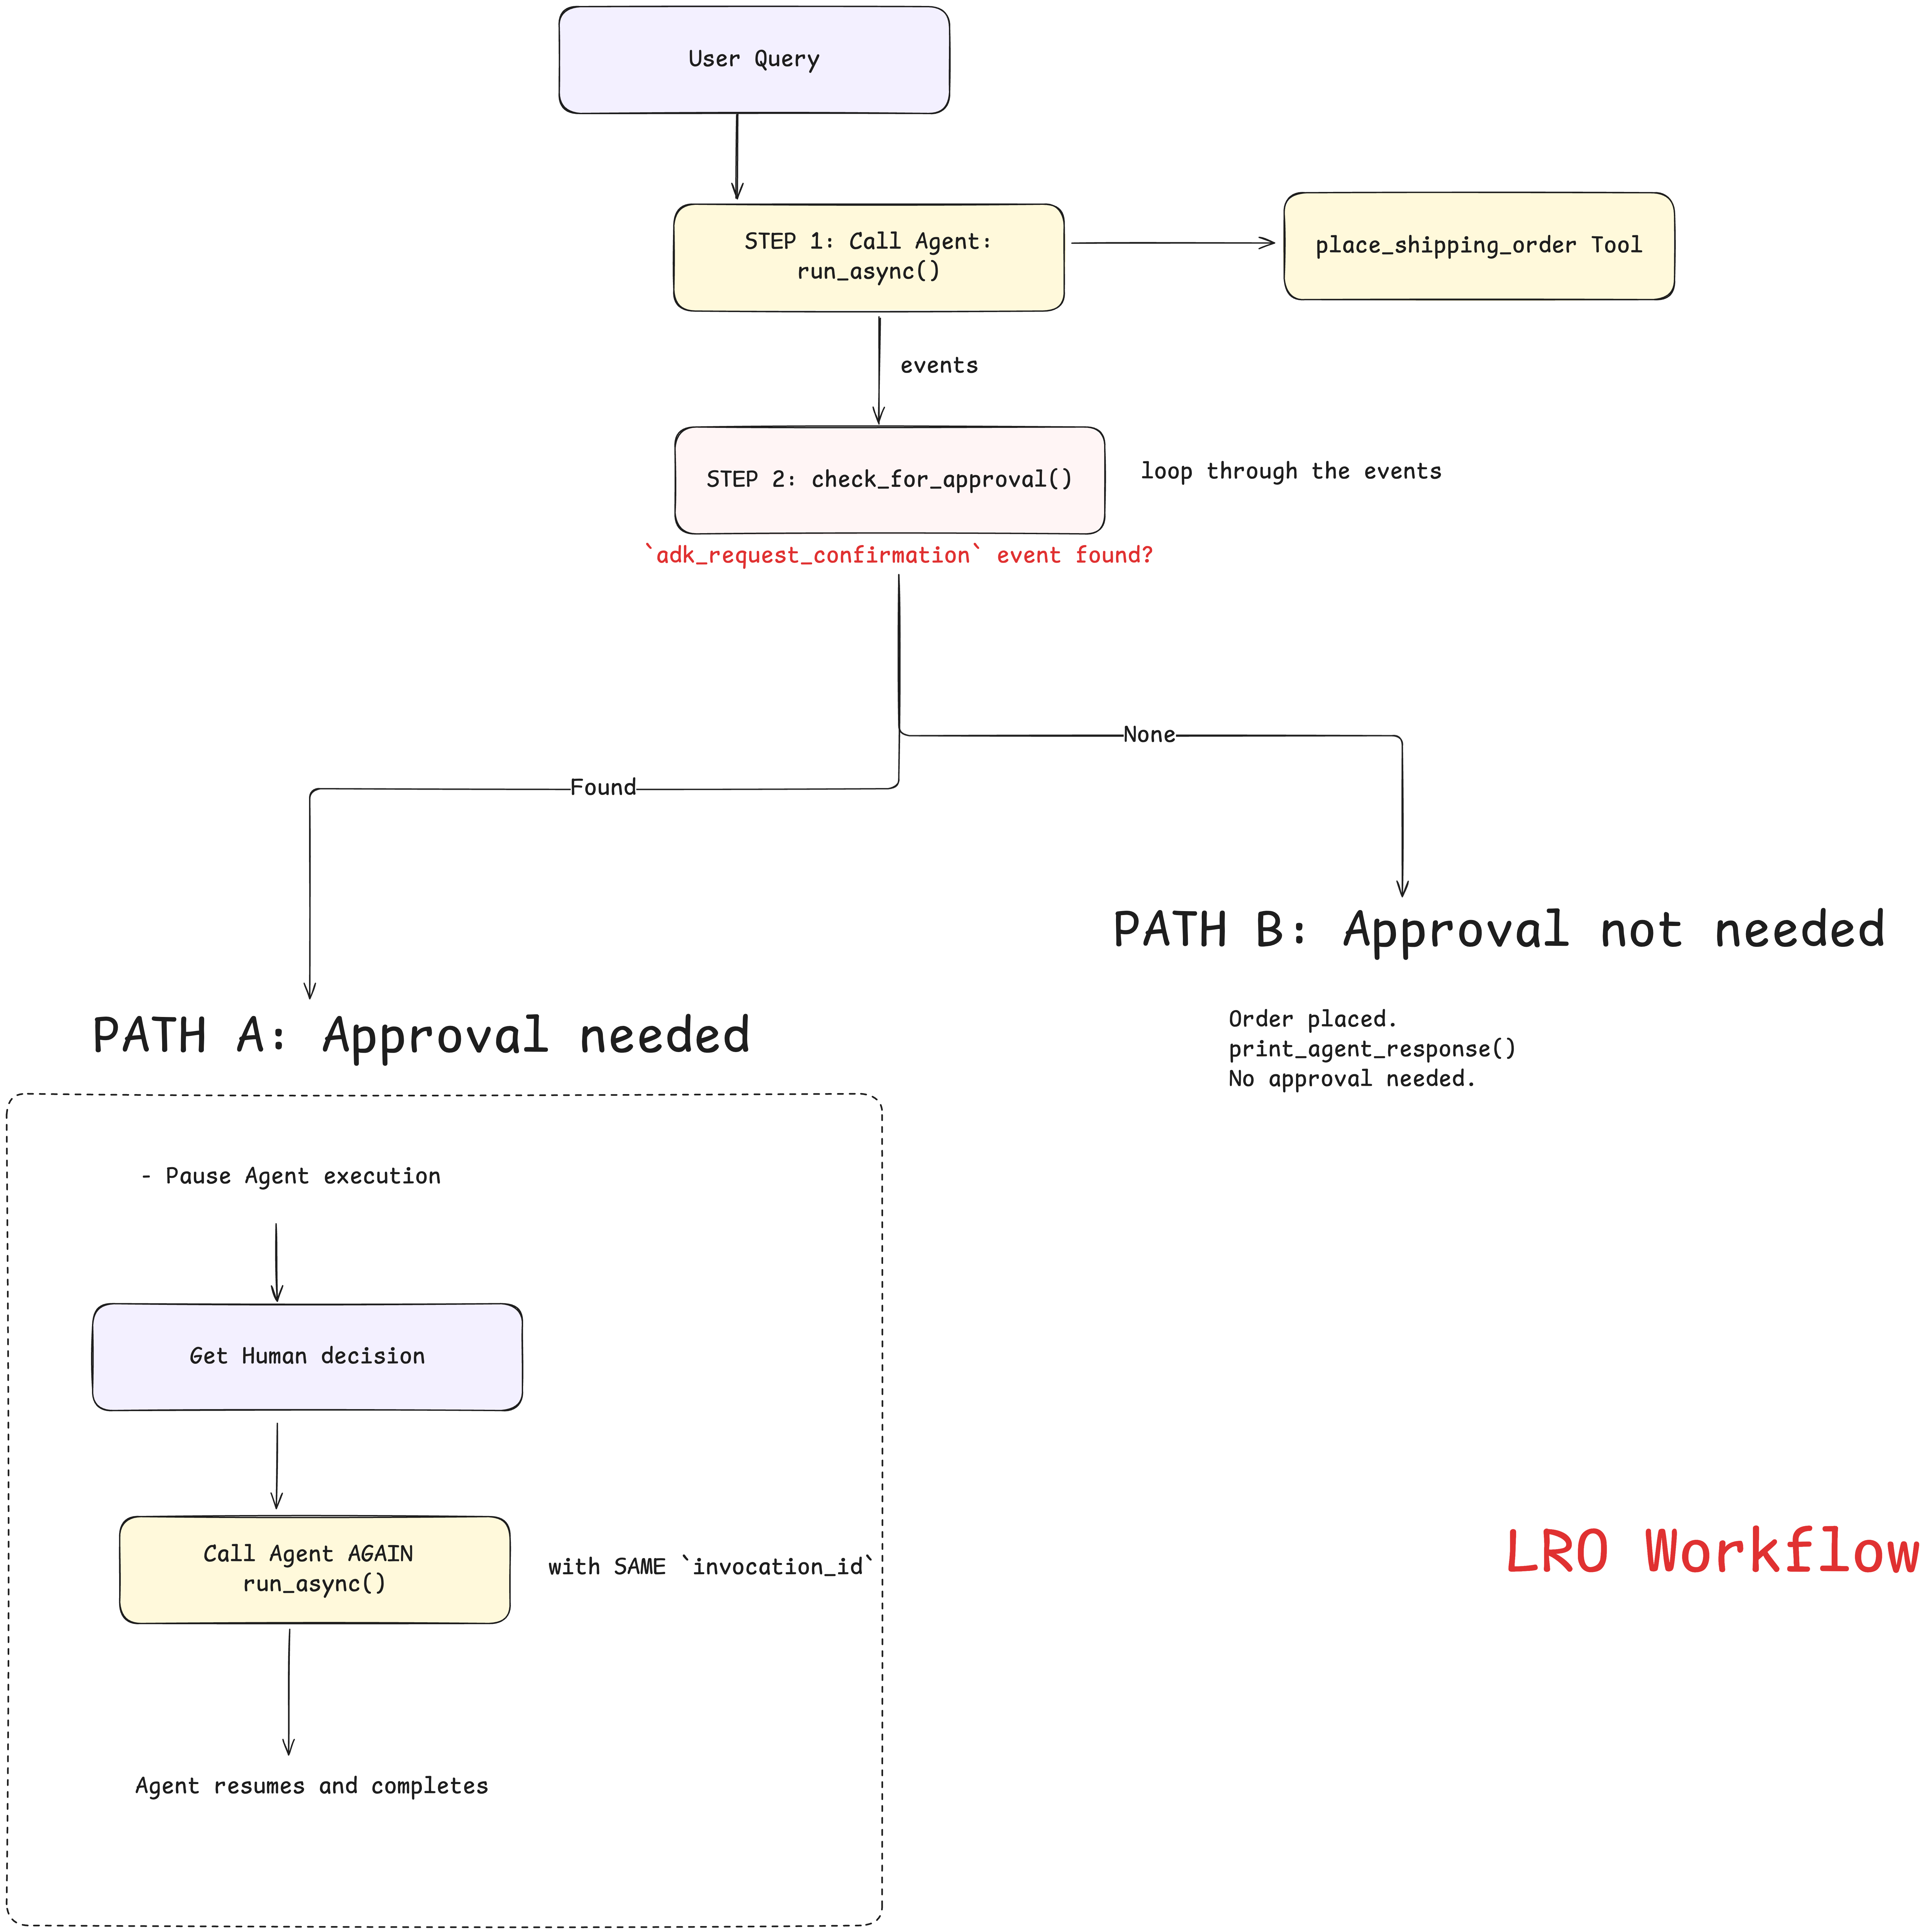

In [ ]:
async def run_shipping_workflow(query: str, auto_approve: bool = True):
  """Runs a shipping workflow with approval handling.

  Args:
      query: User's shipping request
      auto_approve: Whether to auto-approve large orders (simulates human decision)
  """

  print(f"\n{'='*60}")
  print(f"User > {query}\n")

  # Generate unique session ID
  session_id = f"order_{uuid.uuid4().hex[:8]}"

  # Create session
  await session_service.create_session(
      app_name="shipping_coordinator", user_id="test_user", session_id=session_id
  )

  query_content = types.Content(role="user", parts=[types.Part(text=query)])
  events = []

  # STEP 1: Send initial request to the Agent. If num_containers > 5, the Agent returns the special `adk_request_confirmation` event
  async for event in shipping_runner.run_async(
      user_id="test_user", session_id=session_id, new_message=query_content
  ):
      events.append(event)

  # STEP 2: Loop through all the events generated and check if `adk_request_confirmation` is present.
  approval_info = check_for_approval(events)

  # STEP 3: If the event is present, it's a large order - HANDLE APPROVAL WORKFLOW
  if approval_info:
      print(f"⏸Pausing for approval")
      print(f"Human Decision: {'APPROVE ' if auto_approve else 'REJECT '}\n")

      # PATH A: Resume the agent by calling run_async() again with the approval decision
      async for event in shipping_runner.run_async(
          user_id="test_user",
          session_id=session_id,
          new_message=create_approval_response(
              approval_info, auto_approve
          ),  # Send human decision here
          invocation_id=approval_info[
              "invocation_id"
          ],  # Critical: same invocation_id tells ADK to RESUME
      ):
          if event.content and event.content.parts:
              for part in event.content.parts:
                  if part.text:
                      print(f"Agent > {part.text}")

  else:
      # PATH B: If the `adk_request_confirmation` is not present - no approval needed - order completed immediately.
      print_agent_response(events)

  print(f"{'='*60}\n")

**Code breakdown**
- Step 1: Send initial request to the Agent
  - Call `run_async()` to start agent execution
  - Collect all events in a list for inspection

- Step 2: Detect Pause
  - Call `check_for_approval(events)` to look for the special event: `adk_request_confirmation`
  - Returns approval info (with `invocation_id`) if the special event is present;
  - None if completed

- Step 3: Resume execution
  - PATH A:
    - If the approval info is present, at this point the Agent pauses for human input.
    - Once the Human input is available, call the agent again using `run_async()` and pass in the Human input.
    - **Critical**: Same `invocation_id` (tells ADK to RESUME, not restart)
    - Display agent's final response after resuming

  - PATH B:
    - If the approval info is not present, then approval is not needed and the agent completes execution.

### 2.4) Testing the Workflow

Now, let's run our demos. Notice how much cleaner and easier to read they are. All the complex logic for pausing and resuming is now hidden away in our `run_workflow` helper function, allowing us to focus on the tasks we want the agent to perform.

Note: You may see warnings like `Warning: there are non-text parts in the response: ['function_call']` - this is normal and can be ignored. It just means the agent is calling tools in addition to generating text.

In [ ]:
# Demo 1: It's a small order. Agent receives auto-approved status from tool
await run_shipping_workflow("Ship 3 containers to Singapore")

# Demo 2: Workflow simulates human decision: APPROVE
await run_shipping_workflow("Ship 10 containers to Rotterdam", auto_approve=True)

# Demo 3: Workflow simulates human decision: REJECT
await run_shipping_workflow("Ship 8 containers to Los Angeles", auto_approve=False)


User > Ship 3 containers to Singapore

Agent > The order for 3 containers to Singapore has been approved. The order ID is ORD-3-AUTO.


User > Ship 10 containers to Rotterdam



/usr/local/lib/python3.12/dist-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.TOOL_CONFIRMATION is enabled.
  check_feature_enabled()
/usr/local/lib/python3.12/dist-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.AGENT_STATE is enabled.
  check_feature_enabled()


⏸Pausing for approval
Human Decision: APPROVE 

Agent > Shipping order approved. Order ID: ORD-10-HUMAN. 10 containers to Rotterdam.


User > Ship 8 containers to Los Angeles

⏸Pausing for approval
Human Decision: REJECT 

Agent > The order for 8 containers to Los Angeles has been rejected and is pending approval.



<b><u>Complete Execution Flow</u></b>

Here's an example trace of the whole workflow.

Tool pauses at `TIME 6`, workflow detects it at `TIME 8`, resumes at `TIME 10` with same `invocation_id="abc123"`.

Detailed timeline:

Here's what happens step-by-step when you run `run_shipping_workflow("Ship 10 containers to Rotterdam", auto_approve=True)`:
```
TIME 1: User sends "Ship 10 containers to Rotterdam"
        ↓
TIME 2: Workflow calls shipping_runner.run_async(...)
        ADK assigns a unique invocation_id = "abc123"
        ↓
TIME 3: Agent receives user message, decides to use place_shipping_order tool
        ↓
TIME 4: ADK calls place_shipping_order(10, "Rotterdam", tool_context)
        ↓
TIME 5: Tool checks: num_containers (10) > 5
        Tool calls tool_context.request_confirmation(...)
        ↓
TIME 6: Tool returns {'status': 'pending', ...}
        ↓
TIME 7: ADK creates adk_request_confirmation event with invocation_id="abc123"
        ↓
TIME 8: Workflow detects the event via check_for_approval()
        Saves approval_id and invocation_id="abc123"
        ↓
TIME 9: Workflow gets human decision → True (approve)
        ↓
TIME 10: Workflow calls shipping_runner.run_async(..., invocation_id="abc123")
         Passes approval decision as FunctionResponse
         ↓
TIME 11: ADK sees invocation_id="abc123" - knows to RESUME (instead of starting new)
         Loads saved state from TIME 7
         ↓
TIME 12: ADK calls place_shipping_order again with same parameters
         But now tool_context.tool_confirmation.confirmed = True
         ↓
TIME 13: Tool returns {'status': 'approved', 'order_id': 'ORD-10-HUMAN', ...}
         ↓
TIME 14: Agent receives result and responds to user
```

Key point: The `invocation_id` is how ADK knows to resume the paused execution instead of starting a new one.



---

We implemented two powerful, production-ready patterns for extending agent's capabilities beyond simple functions.

| Pattern | When To Use It | Key ADK Components |
| -------- | -------- | -------- |
| MCP Integration | You need to connect to external, standardized services (like time, databases, or file systems)<br> without writing custom integration code. | McpToolset |
| Long-Running Operations | You need to pause a workflow to wait for an external event, most commonly for <br>human-in-the-loop approvals or long background tasks or for compliance/security checkpoints. | ToolContext, request_confirmation, App, ResumabilityConfig |

- Production Ready Concepts
You now understand how to build agents that:
  - 🌐 Scale: Leverage community tools instead of building everything
  - ⏳ Handle Time: Manage operations that span minutes, hours, or days
  - 🔒 Ensure Compliance: Add human oversight to critical operations
  - 🔄 Maintain State: Resume conversations exactly where they paused

Start Simple: `Begin with custom tools → Add MCP services → Add long-running as needed`

# 3. Exercise

Build an agent that generates images using the MCP server, but requires approval for "bulk" image generation:

- Single image request (1 image): Auto-approve, generate immediately
- Bulk request (>1 image): Pause and ask for approval before generating multiple images
- Explore different publicly available Image Generation MCP Servers

In [ ]:
!pip install -q langchain langchain-google-genai langchain-community
!pip install -q langgraph
!pip install -q mcp httpx
!pip install -q pillow requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.7/502.7 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
import os
from google.colab import userdata

# Set your Gemini API key (store it in Colab Secrets as GEMINI_API_KEY)
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from typing import Literal
import json
import requests
from IPython.display import display, Image as IPImage
import base64

In [ ]:
# Overview of publicly available Image Generation MCP Servers
image_mcp_servers = {
    "Replicate MCP": {
        "url": "https://github.com/deepfates/mcp-replicate",
        "description": "Access Replicate's models including SDXL, Flux, etc.",
        "requires": "REPLICATE_API_TOKEN",
        "models": ["black-forest-labs/flux-schnell", "stability-ai/sdxl"]
    },
    "Hugging Face MCP": {
        "url": "https://github.com/evalstate/mcp-hfspace",
        "description": "Run HuggingFace Space models via MCP",
        "requires": "HF_TOKEN (optional)",
        "models": ["FLUX.1-schnell", "SDXL-Turbo"]
    }
}

print("📚 Available Image Generation MCP Servers:\n")
for name, info in image_mcp_servers.items():
    print(f"🔧 {name}")
    print(f"   URL: {info['url']}")
    print(f"   Description: {info['description']}")
    print(f"   Requires: {info['requires']}")
    print(f"   Models: {', '.join(info['models'])}")
    print()

📚 Available Image Generation MCP Servers:

🔧 Replicate MCP
   URL: https://github.com/deepfates/mcp-replicate
   Description: Access Replicate's models including SDXL, Flux, etc.
   Requires: REPLICATE_API_TOKEN
   Models: black-forest-labs/flux-schnell, stability-ai/sdxl

🔧 Hugging Face MCP
   URL: https://github.com/evalstate/mcp-hfspace
   Description: Run HuggingFace Space models via MCP
   Requires: HF_TOKEN (optional)
   Models: FLUX.1-schnell, SDXL-Turbo



In [ ]:
# Simulated MCP image generation via Pollinations.ai (FREE, no API key needed!)
# This simulates what a real MCP server would do

@tool
def generate_image_via_mcp(prompt: str, count: int = 1, width: int = 512, height: int = 512) -> dict:
    """
    Generate images using a publicly available image generation service (simulating MCP server call).
    Uses Pollinations.ai - completely free, no API key required.

    Args:
        prompt: Text description of the image to generate
        count: Number of images to generate (1 for single, >1 for bulk)
        width: Image width in pixels
        height: Image height in pixels

    Returns:
        dict with image URLs and metadata
    """
    import urllib.parse
    import time

    generated_images = []

    for i in range(count):
        # Pollinations.ai - free image generation API (simulates MCP behavior)
        seed = int(time.time()) + i  # Different seed for each image
        encoded_prompt = urllib.parse.quote(f"{prompt} variation {i+1}" if count > 1 else prompt)
        image_url = f"https://image.pollinations.ai/prompt/{encoded_prompt}?width={width}&height={height}&seed={seed}&nologo=true"

        generated_images.append({
            "index": i + 1,
            "url": image_url,
            "prompt": prompt,
            "seed": seed
        })

    return {
        "status": "success",
        "mcp_server": "Pollinations.ai (Free MCP-compatible endpoint)",
        "total_generated": count,
        "images": generated_images
    }

@tool
def check_image_count(user_request: str) -> dict:
    """
    Parse the user's request to determine how many images they want.
    Returns count and whether this is a bulk request requiring approval.

    Args:
        user_request: The user's natural language request

    Returns:
        dict with count and is_bulk flag
    """
    import re

    # Look for number patterns
    numbers = re.findall(r'\b(\d+)\b', user_request)
    words_to_nums = {
        'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
        'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
        'a few': 3, 'several': 5, 'many': 10, 'couple': 2
    }

    count = 1  # default
    for word, num in words_to_nums.items():
        if word in user_request.lower():
            count = num
            break

    if numbers:
        count = int(numbers[0])

    return {
        "requested_count": count,
        "is_bulk": count > 1,
        "requires_approval": count > 1
    }

print("✅ Tools defined successfully!")

✅ Tools defined successfully!


In [ ]:
# Build the LangGraph agent with human-in-the-loop

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import json

# Initialize Gemini LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0.7
)

tools = [check_image_count, generate_image_via_mcp]
llm_with_tools = llm.bind_tools(tools)

# System Prompt
SYSTEM_PROMPT = """You are an AI image generation agent that uses MCP (Model Context Protocol) servers to generate images.

WORKFLOW RULES:
1. When a user requests images, FIRST use check_image_count tool to determine how many images they want.
2. If count == 1 (single image): Auto-approve and immediately call generate_image_via_mcp
3. If count > 1 (bulk request): DO NOT generate yet. Instead, respond with:
   "⚠️ BULK REQUEST DETECTED: You requested {count} images. Do you approve generating {count} images? (yes/no)"
   Then WAIT for the user's approval before proceeding.
4. Only generate bulk images after explicit user approval (user says "yes", "approve", "proceed", etc.)
5. If user denies bulk request, acknowledge and offer to generate just 1 image instead.

Always be helpful and display the image URLs after generation."""

#  Agent Node
def agent_node(state: MessagesState):
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# Routing Logic
def should_continue(state: MessagesState) -> Literal["tools", "human_approval", END]:
    last_message = state["messages"][-1]

    # If no tool calls, end
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return END

    # Check if any tool call is generate_image_via_mcp with count > 1
    for tool_call in last_message.tool_calls:
        if tool_call["name"] == "generate_image_via_mcp":
            args = tool_call.get("args", {})
            if args.get("count", 1) > 1:
                return "human_approval"  # Pause for approval

    return "tools"

# Human Approval Node
def human_approval_node(state: MessagesState):
    """This node pauses and waits for human input via interrupt"""
    last_message = state["messages"][-1]

    # Extract details from pending tool call
    for tool_call in last_message.tool_calls:
        if tool_call["name"] == "generate_image_via_mcp":
            count = tool_call["args"].get("count", 1)
            prompt = tool_call["args"].get("prompt", "")

    print(f"\n{'='*60}")
    print(f"⚠️  BULK IMAGE GENERATION REQUEST")
    print(f"{'='*60}")
    print(f"📝 Prompt: {prompt}")
    print(f"🔢 Count: {count} images")
    print(f"{'='*60}")
    approval = input("Do you approve generating these images? (yes/no): ").strip().lower()

    if approval in ["yes", "y", "approve", "ok", "proceed", "sure"]:
        print("✅ Approved! Generating images...")
        # Return approval message so agent continues
        return {"messages": [HumanMessage(content=f"Yes, approved. Please generate the {count} images now.")]}
    else:
        print("❌ Rejected. Cancelling bulk generation.")
        return {"messages": [HumanMessage(content="No, cancel the bulk generation. Just generate 1 image instead if they still want it.")]}

# Build Graph
tool_node = ToolNode(tools)

graph_builder = StateGraph(MessagesState)
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("human_approval", human_approval_node)

graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges("agent", should_continue)
graph_builder.add_edge("tools", "agent")
graph_builder.add_edge("human_approval", "agent")  # After approval, re-run agent

# Compile with memory (enables multi-turn conversation)
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

print("✅ Agent graph compiled successfully!")

✅ Agent graph compiled successfully!


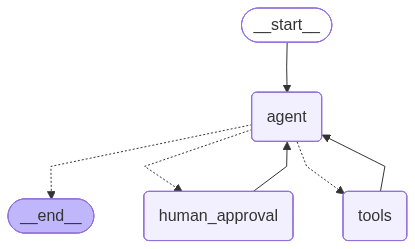

In [ ]:
# Visualize the agent graph
from IPython.display import Image as IPImage, display

try:
    graph_image = graph.get_graph().draw_mermaid_png()
    display(IPImage(graph_image))
except Exception as e:
    print(f"Graph visualization: {e}")
    print("\n📊 Graph Structure:")
    print("START → agent → [tools / human_approval / END]")
    print("tools → agent")
    print("human_approval → agent")

In [ ]:
# Helper to display generated images
import requests
from IPython.display import display, Image as IPImage, HTML

def display_generated_images(response_messages):
    """Parse agent response and display any generated images"""
    for msg in response_messages:
        if hasattr(msg, 'content'):
            content = msg.content if isinstance(msg.content, str) else str(msg.content)
            # Look for image URLs in tool results
            if 'pollinations.ai' in content or 'image_url' in content.lower():
                try:
                    # Try to parse JSON tool results
                    data = json.loads(content)
                    if 'images' in data:
                        print(f"\n🖼️ Generated {data['total_generated']} image(s):")
                        for img in data['images']:
                            print(f"\n  Image {img['index']}: {img['url']}")
                            display(IPImage(url=img['url'], width=300))
                except:
                    pass

def run_agent(user_input: str, thread_id: str = "default"):
    """Run the image generation agent"""
    config = {"configurable": {"thread_id": thread_id}}

    print(f"\n👤 User: {user_input}")
    print("-" * 50)

    result = graph.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=config
    )

    # Display final agent response
    final_message = result["messages"][-1]
    if hasattr(final_message, 'content') and final_message.content:
        print(f"\n🤖 Agent: {final_message.content}")

    # Try to display images from tool results
    display_generated_images(result["messages"])

    return result

In [ ]:
print("=" * 60)
print("TEST 1: Single Image Request (Auto-Approved)")
print("=" * 60)
result = run_agent("Generate 1 image of a sunset over mountains", thread_id="test1")

TEST 1: Single Image Request (Auto-Approved)

👤 User: Generate 1 image of a sunset over mountains
--------------------------------------------------

🖼️ Generated 1 image(s):

  Image 1: https://image.pollinations.ai/prompt/sunset%20over%20mountains?width=512&height=512&seed=1772920973&nologo=true


In [ ]:
print("=" * 60)
print("TEST 2: Bulk Image Request (Requires Approval)")
print("=" * 60)
result = run_agent("Generate 4 images of futuristic cities at night", thread_id="test2")
# You will be prompted in the terminal to approve/deny!

TEST 2: Bulk Image Request (Requires Approval)

👤 User: Generate 4 images of futuristic cities at night
--------------------------------------------------

🤖 Agent: ⚠️ BULK REQUEST DETECTED: You requested 4 images. Do you approve generating 4 images? (yes/no)


In [ ]:
# Cell 10: Test 3 - Interactive chat
print("=" * 60)
print("TEST 3: Interactive Session")
print("=" * 60)

thread = "interactive_session"
while True:
    user_input = input("\n👤 You (or 'quit'): ").strip()
    if user_input.lower() in ['quit', 'exit', 'q']:
        print("Goodbye!")
        break
    if user_input:
        run_agent(user_input, thread_id=thread)

# Resources
1. https://www.kaggle.com/learn-guide/5-day-agents
2. https://www.kaggle.com/code/kaggle5daysofai/day-2a-agent-tools
3. https://www.kaggle.com/code/kaggle5daysofai/day-2b-agent-tools-best-practices
4. <a href="https://github.com/modelcontextprotocol/servers/tree/main/src/everything">MCP Servers Link to Github</a>
5. <a href="https://modelcontextprotocol.io/examples">MCP Examples</a>